# Week 5: PyTorch, Optimization, and Convolutional Neural Networks

**Lecture 9:** Optimizers, initializers, and vanishing gradients  
**Lecture 10:** Convolutional neural networks (CNNs)

This is our first PyTorch week. The notebook separates the responsibilities of datasets, transforms, data loaders, models, losses, optimizers, training, validation, and regularization so each part can be inspected independently.

# Lecture 9: Optimizers, Initializers, and Vanishing Gradients

## The PyTorch Training Stack

A standard supervised PyTorch project has the following pieces:

1. A `Dataset` defines how to retrieve one example and its label.
2. A transform converts and optionally augments an example.
3. A `DataLoader` builds batches, shuffles training data, and moves data loading outside the model.
4. An `nn.Module` maps tensors to logits.
5. A loss function maps logits and labels to one scalar.
6. `loss.backward()` uses autograd to populate parameter gradients.
7. An optimizer updates parameters from those gradients.
8. A validation loop measures generalization without updating parameters.

PyTorch models produce **logits**. `CrossEntropyLoss` performs the numerically stable softmax and negative log-likelihood internally, so do not put a softmax layer at the end of a multiclass training model.

In [1]:
from copy import deepcopy
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
device: cuda
GPU: NVIDIA GeForce RTX 3090


## Tensors and Autograd

PyTorch tensors resemble NumPy arrays, but tensors can live on accelerators and record operations for automatic differentiation. If a scalar loss $L$ depends on a tensor $w$ with `requires_grad=True`, `L.backward()` computes $\nabla_w L$ and stores it in `w.grad`.

In [2]:
w = torch.tensor([2.0, -1.0], requires_grad=True)
loss = (w**2).sum()
loss.backward()

print("w:", w.detach())
print("L(w):", loss.item())
print("autograd gradient:", w.grad)
print("analytical gradient 2w:", 2 * w.detach())

w: tensor([ 2., -1.])
L(w): 5.0
autograd gradient: tensor([ 4., -2.])
analytical gradient 2w: tensor([ 4., -2.])


## Datasets, Transforms, and DataLoaders

Imagenette2 is a 10-class subset of ImageNet with natural images at varied resolutions. This notebook expects its `train/` and `val/` folders under the shared `../../datasets/imagenette2` directory.

Training transforms contain randomness. Random cropping and horizontal flipping create new plausible views of an image and act as **data augmentation**. Validation transforms are deterministic because validation should measure the model, not the luck of a random crop.

`DataLoader` controls:

- `batch_size`: examples per optimizer update;
- `shuffle=True`: changes training order each epoch;
- `num_workers`: worker processes that prepare batches;
- `pin_memory=True`: speeds host-to-GPU copies when CUDA is used.

`TRAINING_SIZE` makes dataset-size experiments explicit. It is set to `None` for the full run, so every Imagenette2 training image is used. Set it to an integer only when you intentionally want a shorter classroom experiment.

In [3]:
DATA_ROOT = Path("../../datasets/imagenette2")
CHECKPOINT_DIRECTORY = Path("checkpoints")
CHECKPOINT_DIRECTORY.mkdir(parents=True, exist_ok=True)
IMAGE_SIZE = 96
BATCH_SIZE = 128
TRAINING_SIZE = None  # Full Imagenette2 training split: 9,469 images.
MLP_EPOCHS = 30
CNN_EPOCHS = 50
MLP_PATIENCE = 6
CNN_PATIENCE = 8
MINIMUM_IMPROVEMENT = 1e-4

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

training_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

evaluation_transform = transforms.Compose([
    transforms.Resize(112),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

training_source = datasets.ImageFolder(
    root=DATA_ROOT / "train", transform=training_transform
)
validation_dataset = datasets.ImageFolder(
    root=DATA_ROOT / "val", transform=evaluation_transform
)

training_indices = list(range(len(training_source)))
if TRAINING_SIZE is not None:
    generator = torch.Generator().manual_seed(SEED)
    training_indices = torch.randperm(
        len(training_source), generator=generator
    )[:TRAINING_SIZE].tolist()

training_dataset = Subset(training_source, training_indices)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": device.type == "cuda",
    "persistent_workers": True,
}
training_loader = DataLoader(training_dataset, shuffle=True, **loader_options)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)

print(f"training examples:   {len(training_dataset):,}")
print(f"validation examples: {len(validation_dataset):,}")
print("classes:", training_source.classes)

training examples:   9,469
validation examples: 3,925
classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


image batch shape: torch.Size([128, 3, 96, 96])
label batch shape: torch.Size([128])


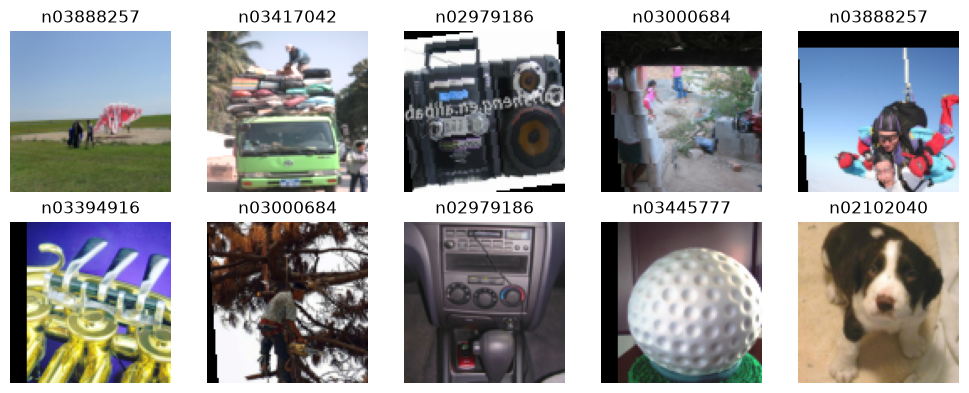

In [4]:
images, labels = next(iter(training_loader))
print("image batch shape:", images.shape)
print("label batch shape:", labels.shape)

def denormalize(image):
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for image, label, axis in zip(images[:10], labels[:10], axes.ravel()):
    axis.imshow(denormalize(image).permute(1, 2, 0))
    axis.set_title(training_source.classes[label])
    axis.axis("off")
plt.tight_layout()
plt.show()

## Deeper and Wider MLPs

A **wider** network has more units per layer and can represent more features at a given depth. A **deeper** network composes more transformations and can build hierarchical representations. Both increase capacity and compute.

Capacity is useful only when optimization and generalization are controlled:

- Too narrow or shallow can underfit: training and validation losses remain high.
- Larger models can reduce training loss but overfit limited datasets.
- Deeper sigmoid/tanh networks are vulnerable to vanishing gradients.
- Deeper networks also require careful initialization and later benefit from residual connections.

The MLP below exposes width, depth, and dropout. It is a baseline: flattening an image discards spatial structure, which motivates CNNs in Lecture 10.

In [5]:
class ImageMLP(nn.Module):
    def __init__(
        self,
        hidden_width=512,
        hidden_depth=2,
        dropout_probability=0.3,
        number_of_classes=10,
    ):
        super().__init__()
        layers = [nn.Flatten()]
        input_features = 3 * IMAGE_SIZE * IMAGE_SIZE

        for _ in range(hidden_depth):
            layers.extend([
                nn.Linear(input_features, hidden_width),
                nn.ReLU(),
                nn.Dropout(dropout_probability),
            ])
            input_features = hidden_width

        layers.append(nn.Linear(input_features, number_of_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, X):
        return self.network(X)


mlp = ImageMLP(hidden_width=256, hidden_depth=3).to(device)
logits = mlp(images.to(device))
print(mlp)
print("logit shape:", logits.shape)

ImageMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=27648, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=256, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=256, out_features=10, bias=True)
  )
)
logit shape: torch.Size([128, 10])


## Initializers and Vanishing/Exploding Gradients

For a layer $z^{(\ell)}=a^{(\ell-1)}W^{(\ell)}+b^{(\ell)}$, backpropagation repeatedly multiplies by weight matrices and activation derivatives:

$$\delta^{(\ell)}=\left(\delta^{(\ell+1)}(W^{(\ell+1)})^T\right)\odot\phi'\!\left(z^{(\ell)}\right).$$

Across many layers, products with norms below one make gradients **vanish**; products with norms above one make them **explode**. Saturating sigmoid and tanh derivatives make vanishing especially likely.

Initialization attempts to preserve activation and gradient variance:

- **Xavier/Glorot**, useful for tanh or sigmoid:
  $$\operatorname{Var}(W_{ij})\approx\frac{2}{n_{\mathrm{in}}+n_{\mathrm{out}}}.$$
- **He/Kaiming**, designed for ReLU:
  $$\operatorname{Var}(W_{ij})\approx\frac{2}{n_{\mathrm{in}}}.$$

Biases commonly start at zero. PyTorch modules have sensible defaults, but explicit initialization makes the assumption visible.

In [6]:
def initialize_model(model, method="he"):
    for module in model.modules():
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            if method == "xavier":
                nn.init.xavier_normal_(module.weight)
            elif method == "he":
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
            elif method == "small_normal":
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
            else:
                raise ValueError(f"unknown initialization method: {method}")
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    return model


def gradient_norms_by_layer(model):
    return {
        name: parameter.grad.norm().item()
        for name, parameter in model.named_parameters()
        if parameter.grad is not None and name.endswith("weight")
    }


for method in ("small_normal", "xavier", "he"):
    probe = initialize_model(
        ImageMLP(hidden_width=128, hidden_depth=8, dropout_probability=0.0),
        method,
    ).to(device)
    probe.zero_grad()
    probe_loss = nn.CrossEntropyLoss()(probe(images.to(device)), labels.to(device))
    probe_loss.backward()
    norms = gradient_norms_by_layer(probe)
    first_norm = next(iter(norms.values()))
    last_norm = next(reversed(norms.values()))
    print(
        f"{method:>12} | first-layer grad: {first_norm:10.3e} "
        f"| last-layer grad: {last_norm:10.3e}"
    )

small_normal | first-layer grad:  3.656e-08 | last-layer grad:  3.753e-08
      xavier | first-layer grad:  1.566e+00 | last-layer grad:  1.260e-01
          he | first-layer grad:  3.388e+01 | last-layer grad:  9.943e+00


## Optimizers in Unified Notation

Let $w_t$ collect every trainable parameter and let

$$g_t=\nabla_w L_{B_t}(w_t)$$

be the gradient computed from mini-batch $B_t$. The learning rate is $\alpha$.

### SGD

$$w_{t+1}=w_t-\alpha g_t.$$

### Momentum

Momentum accumulates a velocity, reducing oscillation and carrying progress through consistent directions:

$$m_t=\beta m_{t-1}+(1-\beta)g_t,$$
$$w_{t+1}=w_t-\alpha m_t.$$

PyTorch's SGD momentum uses an equivalent convention with a differently scaled velocity buffer.

### RMSProp

RMSProp tracks a moving average of squared gradients and divides by its root:

$$v_t=\rho v_{t-1}+(1-\rho)g_t^2,$$
$$w_{t+1}=w_t-\alpha\frac{g_t}{\sqrt{v_t}+\epsilon}.$$

The denominator produces an **adaptive learning rate for each parameter**: coordinates with persistently large gradients get smaller effective steps, while coordinates with small gradients get relatively larger steps.

### Adam

Adam combines momentum and adaptive scaling:

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,$$
$$v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2,$$
$$\widehat m_t=\frac{m_t}{1-\beta_1^t},\qquad
\widehat v_t=\frac{v_t}{1-\beta_2^t},$$
$$w_{t+1}=w_t-\alpha\frac{\widehat m_t}{\sqrt{\widehat v_t}+\epsilon}.$$

Adam's key feature is not merely momentum: it adapts the effective step size coordinate by coordinate. Adam often learns quickly with little tuning, while well-tuned SGD with momentum can generalize extremely well in vision.

### AdamW and Weight Decay

AdamW decouples weight decay from the adaptive gradient update:

$$w_{t+1}=(1-\alpha\lambda)w_t
-\alpha\frac{\widehat m_t}{\sqrt{\widehat v_t}+\epsilon}.$$

This separation makes the shrinkage controlled by $\lambda$ easier to interpret than placing an L2 term inside Adam's adaptively scaled gradient.

In [7]:
def make_optimizer(name, parameters, alpha, weight_decay=0.0):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(
            parameters, lr=alpha, weight_decay=weight_decay
        )
    if name == "momentum":
        return torch.optim.SGD(
            parameters,
            lr=alpha,
            momentum=0.9,
            nesterov=True,
            weight_decay=weight_decay,
        )
    if name == "rmsprop":
        return torch.optim.RMSprop(
            parameters,
            lr=alpha,
            alpha=0.99,
            momentum=0.9,
            weight_decay=weight_decay,
        )
    if name == "adam":
        return torch.optim.Adam(
            parameters, lr=alpha, weight_decay=weight_decay
        )
    if name == "adamw":
        return torch.optim.AdamW(
            parameters, lr=alpha, weight_decay=weight_decay
        )
    raise ValueError(f"unknown optimizer: {name}")

## Regularization and Generalization

Regularization aims to reduce the gap between training performance and performance on unseen data.

| Method | Training behavior | PyTorch location |
|---|---|---|
| More data | Reduces reliance on individual examples | `TRAINING_SIZE` / dataset |
| Augmentation | Creates label-preserving variations | training transforms |
| Dropout | Randomly masks activations during training | `nn.Dropout` |
| Weight decay | Shrinks weights | optimizer `weight_decay` |
| Early stopping | Stops when validation loss no longer improves | `fit_model` |

Watch both losses. If training loss keeps falling while validation loss rises, the model is overfitting. If both remain high, the model is underfitting or optimization is failing. A larger dataset usually delays overfitting; a larger model usually makes fitting training data easier but does not guarantee better validation performance.

### Early stopping as our default

For most experiments in this course, we will specify a generous **maximum** number of epochs and let validation loss decide when to stop. After every epoch:

1. train on the training split;
2. measure loss on the validation split;
3. save the model if validation loss improves by at least `MINIMUM_IMPROVEMENT`;
4. stop after `patience` consecutive epochs without such an improvement; and
5. restore the weights from the best epoch, not the final epoch.

Patience prevents one noisy validation epoch from ending training. A very small patience can stop during a temporary plateau; a very large patience wastes computation and allows more overfitting. The minimum improvement, sometimes called  `min_delta`, prevents tiny numerical fluctuations from resetting patience. We monitor **validation loss** because it uses the full predicted probability distribution and is usually more sensitive than accuracy.

Early stopping is itself a regularizer: the number of updates is selected using validation data. Consequently, the validation result used for stopping is not an unbiased final test result. When a separate test set exists, use it only once after all choices are fixed. For controlled optimizer comparisons, also keep the split, initialization, maximum epoch budget, patience, and stopping metric fixed.

`model.train()` enables dropout and augmentation happens when the dataset is sampled. `model.eval()` disables dropout. Validation also uses `torch.no_grad()` to avoid constructing an autograd graph.

In [8]:
def run_epoch(model, loader, loss_function, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(X)
            loss = loss_function(logits, y)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_loss += loss.item() * X.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_examples += X.size(0)

    return total_loss / total_examples, total_correct / total_examples


def fit_model(
    model,
    training_loader,
    validation_loader,
    optimizer,
    epochs,
    patience=5,
    minimum_improvement=1e-4,
    scheduler=None,
    checkpoint_path=None,
):
    loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_state = deepcopy(model.state_dict())
    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    print(
        f"{'epoch':>7} {'loss':>11} {'val_loss':>11} "
        f"{'accuracy':>11} {'val_accuracy':>14} {'lr':>10}  status"
    )
    print("-" * 72)

    for epoch in range(1, epochs + 1):
        training_loss, training_accuracy = run_epoch(
            model, training_loader, loss_function, optimizer
        )
        validation_loss, validation_accuracy = run_epoch(
            model, validation_loader, loss_function
        )
        learning_rate = optimizer.param_groups[0]["lr"]
        history.append({
            "epoch": epoch,
            "loss": training_loss,
            "val_loss": validation_loss,
            "accuracy": training_accuracy,
            "val_accuracy": validation_accuracy,
            "learning_rate": learning_rate,
        })
        improved = (
            validation_loss < best_validation_loss - minimum_improvement
        )
        status = "best" if improved else f"wait {epochs_without_improvement + 1}/{patience}"
        print(
            f"{epoch:7d} {training_loss:11.5f} {validation_loss:11.5f} "
            f"{training_accuracy:11.4f} {validation_accuracy:14.4f} "
            f"{learning_rate:10.2e}  {status}"
        )

        if scheduler is not None:
            scheduler.step()

        if improved:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
            if checkpoint_path is not None:
                checkpoint_path = Path(checkpoint_path)
                checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": best_state,
                        "validation_loss": validation_loss,
                        "validation_accuracy": validation_accuracy,
                        "history": history,
                    },
                    checkpoint_path,
                )
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(
                    f"Early stopping at epoch {epoch}: validation loss did "
                    f"not improve for {patience} consecutive epochs."
                )
                break

    model.load_state_dict(best_state)
    print(
        f"Restored epoch {best_epoch} with validation loss "
        f"{best_validation_loss:.5f}."
    )
    if checkpoint_path is not None:
        print(f"best checkpoint: {checkpoint_path}")
    return history

### Optimizer Experiment

The factory makes optimizer changes local: model architecture, initialization, loss, and data stay fixed. The cell below demonstrates AdamW. To compare optimizers fairly, rerun from the same seed and tune each learning rate; using one learning rate for all methods is not a fair benchmark.

In [9]:
mlp = initialize_model(
    ImageMLP(hidden_width=256, hidden_depth=2, dropout_probability=0.3),
    method="he",
).to(device)

optimizer = make_optimizer(
    "adamw", mlp.parameters(), alpha=3e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MLP_EPOCHS
)

mlp_history = fit_model(
    mlp,
    training_loader,
    validation_loader,
    optimizer,
    epochs=MLP_EPOCHS,
    patience=MLP_PATIENCE,
    minimum_improvement=MINIMUM_IMPROVEMENT,
    scheduler=scheduler,
    checkpoint_path=CHECKPOINT_DIRECTORY / "week5_mlp_best.pt",
)

  epoch        loss    val_loss    accuracy   val_accuracy         lr  status
------------------------------------------------------------------------
      1     5.60911     3.69285      0.1651         0.2619   3.00e-04  best
      2     4.19680     2.63237      0.1772         0.2423   2.99e-04  best
      3     3.21862     2.30892      0.1653         0.1997   2.97e-04  best
      4     2.70806     2.28973      0.1630         0.1773   2.93e-04  best
      5     2.54188     2.25673      0.1618         0.1730   2.87e-04  best
      6     2.44820     2.24263      0.1533         0.1778   2.80e-04  best
      7     2.40073     2.23882      0.1508         0.1725   2.71e-04  best
      8     2.35843     2.20846      0.1599         0.2038   2.61e-04  best
      9     2.31290     2.18352      0.1791         0.2260   2.50e-04  best
     10     2.30437     2.17049      0.1896         0.2395   2.38e-04  best
     11     2.27934     2.14270      0.2059         0.2698   2.25e-04  best
     12     2

# Lecture 10: Convolutional Neural Networks

An MLP flattens an image and learns a separate weight for every input-to-hidden connection. A CNN preserves the image grid and reuses each learned filter across spatial locations.

For input channel $c$, output channel $k$, and kernel offsets $(u,v)$, a 2D cross-correlation is

$$z_{i,j,k}=b_k+\sum_c\sum_u\sum_v
W_{u,v,c,k}\,X_{i+u,j+v,c}.$$

Deep-learning libraries conventionally call this operation convolution. The output size in one spatial dimension is

$$H_{\mathrm{out}}=
\left\lfloor\frac{H_{\mathrm{in}}+2P-D(K-1)-1}{S}+1\right\rfloor,$$

where $K$ is kernel size, $S$ stride, $P$ padding, and $D$ dilation.

Key ideas:

- **Local connectivity:** a unit sees a small receptive field.
- **Weight sharing:** one filter detects the same pattern everywhere.
- **Channels:** different filters learn different feature maps.
- **Pooling or strided convolution:** reduces spatial resolution and increases effective receptive field.
- **Hierarchies:** early layers learn edges/textures; later layers combine them into larger patterns.

input shape: torch.Size([1, 3, 96, 96])
feature-map shape: torch.Size([1, 4, 96, 96])


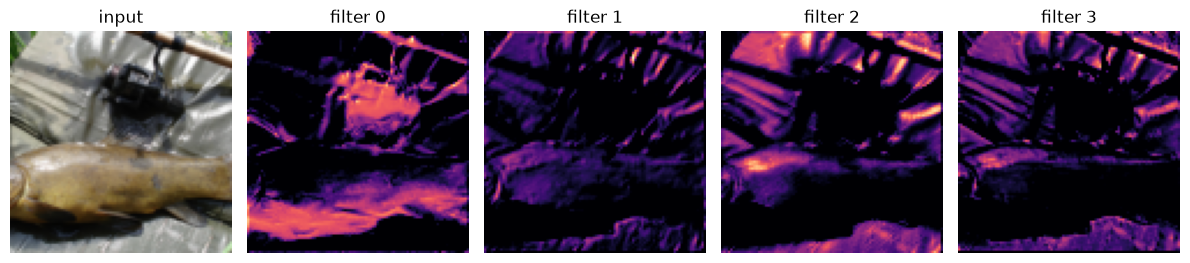

In [10]:
sample_images, _ = next(iter(validation_loader))
sample_image = sample_images[:1].to(device)

edge_filters = nn.Conv2d(3, 4, kernel_size=3, padding=1, bias=False).to(device)
nn.init.kaiming_normal_(edge_filters.weight, nonlinearity="relu")

with torch.no_grad():
    feature_maps = torch.relu(edge_filters(sample_image)).cpu()

print("input shape:", sample_image.shape)
print("feature-map shape:", feature_maps.shape)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(denormalize(sample_image[0]).permute(1, 2, 0))
axes[0].set_title("input")
axes[0].axis("off")
for channel, axis in enumerate(axes[1:]):
    axis.imshow(feature_maps[0, channel], cmap="magma")
    axis.set_title(f"filter {channel}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## A Compact CNN

This baseline has two convolutional blocks. Each block uses convolution, ReLU, and max pooling. Dropout regularizes the classifier. This is intentionally not a deep named architecture; AlexNet, VGG, Inception, and ResNet begin in Week 6.

`AdaptiveAvgPool2d((4, 4))` gives the classifier a known input size and makes the spatial-size transition explicit.

In [11]:
class CompactCNN(nn.Module):
    def __init__(self, number_of_classes=10, dropout_probability=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(128, number_of_classes),
        )

    def forward(self, X):
        return self.classifier(self.features(X))


cnn = initialize_model(CompactCNN(), method="he").to(device)
with torch.no_grad():
    print("CNN logit shape:", cnn(images[:4].to(device)).shape)
print(cnn)

CNN logit shape: torch.Size([4, 10])
CompactCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [12]:
cnn_optimizer = make_optimizer(
    "momentum", cnn.parameters(), alpha=0.02, weight_decay=5e-4
)
cnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    cnn_optimizer, T_max=CNN_EPOCHS
)

cnn_history = fit_model(
    cnn,
    training_loader,
    validation_loader,
    cnn_optimizer,
    epochs=CNN_EPOCHS,
    patience=CNN_PATIENCE,
    minimum_improvement=MINIMUM_IMPROVEMENT,
    scheduler=cnn_scheduler,
    checkpoint_path=CHECKPOINT_DIRECTORY / "week5_cnn_best.pt",
)

  epoch        loss    val_loss    accuracy   val_accuracy         lr  status
------------------------------------------------------------------------
      1     2.18993     1.90309      0.2473         0.3954   2.00e-02  best
      2     1.92366     1.71336      0.3740         0.4925   2.00e-02  best
      3     1.80584     1.63103      0.4344         0.5378   1.99e-02  best
      4     1.71926     1.52630      0.4789         0.5794   1.98e-02  best
      5     1.64987     1.46965      0.5135         0.5977   1.97e-02  best
      6     1.62392     1.47292      0.5316         0.6020   1.95e-02  wait 1/8
      7     1.56620     1.46190      0.5562         0.6054   1.93e-02  best
      8     1.54364     1.37304      0.5679         0.6520   1.90e-02  best
      9     1.51284     1.36133      0.5786         0.6479   1.88e-02  best
     10     1.48671     1.35959      0.5891         0.6576   1.84e-02  best
     11     1.46922     1.34162      0.6002         0.6634   1.81e-02  best
     12  

## Final Validation Evaluation

Imagenette2 provides official training and validation folders but no labeled test split. The report below describes the official validation set. Because validation was also used for early stopping, it should not be described as an unbiased test result.

In [13]:
validation_loss, validation_accuracy = run_epoch(
    cnn, validation_loader, nn.CrossEntropyLoss()
)
print(f"validation loss: {validation_loss:.5f}")
print(f"validation accuracy: {validation_accuracy:.4f}")

all_targets = []
all_predictions = []
cnn.eval()
with torch.no_grad():
    for X, y in validation_loader:
        predictions = cnn(X.to(device)).argmax(dim=1).cpu()
        all_targets.extend(y.numpy())
        all_predictions.extend(predictions.numpy())

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=validation_dataset.classes,
    )
)

validation loss: 0.83053
validation accuracy: 0.7536
              precision    recall  f1-score   support

   n01440764       0.80      0.86      0.83       387
   n02102040       0.75      0.85      0.80       395
   n02979186       0.75      0.78      0.76       357
   n03000684       0.60      0.55      0.57       386
   n03028079       0.83      0.80      0.81       409
   n03394916       0.74      0.75      0.75       394
   n03417042       0.76      0.79      0.78       389
   n03425413       0.75      0.70      0.72       419
   n03445777       0.72      0.67      0.70       399
   n03888257       0.80      0.81      0.81       390

    accuracy                           0.75      3925
   macro avg       0.75      0.75      0.75      3925
weighted avg       0.75      0.75      0.75      3925



## Week 5 Code Takeaways

- PyTorch keeps data, model, loss, optimizer, and training responsibilities separate.
- Initialization controls signal and gradient scale at the start of training.
- Vanishing/exploding gradients arise from repeated Jacobian products.
- SGD, momentum, RMSProp, Adam, and AdamW differ in how they transform $g_t$.
- Adam and RMSProp use coordinate-wise adaptive effective learning rates.
- Dropout, weight decay, augmentation, early stopping, and more data address different aspects of overfitting.
- CNNs preserve spatial structure through local connectivity and weight sharing.
- `Dataset`, transforms, and `DataLoader` separate stored examples, preprocessing, batching, shuffling, and worker behavior.
- `model.train()`, `model.eval()`, and gradient-enabled contexts change runtime behavior even when the forward method is unchanged.
- The reusable loop reports train/validation metrics, restores the best epoch, and writes a commit-friendly model checkpoint.
- Moving the model and every batch to the same `device` makes the same code run on the RTX GPU.
- Week 6 increases depth and introduces modules, Inception paths, and residual connections.